In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import joblib
import warnings
warnings.filterwarnings('ignore')
filepath = r"C:\Users\mites\Downloads\archive (7)\telco_churn.csv"
df = pd.read_csv(filepath)
print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [3]:

# Step 1: Drop useless column
df = df.drop('customerID', axis=1)

# Step 2: TotalCharges fix
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()

# Step 3: Target encode karo (SIRF EK BAAR, SABSE PEHLE)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Step 4: Binary columns encode karo
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'gender']
for col in binary_cols:
    if df[col].dtype == 'object':
        df[col] = LabelEncoder().fit_transform(df[col])

# Step 5: Multi-class columns one-hot encode karo
multi_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity',
              'OnlineBackup', 'DeviceProtection', 'TechSupport',
              'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

print("Shape:", df.shape)
print("Churn unique values:", df['Churn'].unique())
print("Churn NaN:", df['Churn'].isnull().sum())

Shape: (7032, 31)
Churn unique values: [0 1]
Churn NaN: 0


Churn
0    5163
1    1869
Name: count, dtype: int64
Churn
0    0.73
1    0.27
Name: proportion, dtype: float64


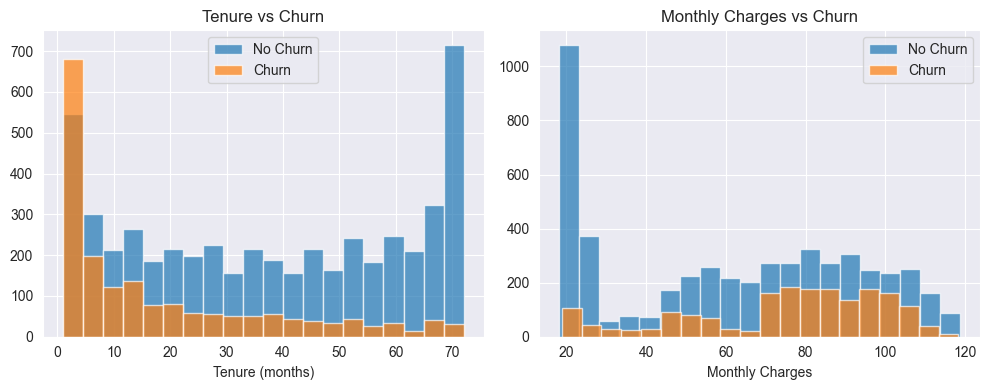

In [4]:
# Churn distribution
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True).round(2))

# Graphs
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
df.groupby('Churn')['tenure'].hist(alpha=0.7, bins=20)
plt.title('Tenure vs Churn')
plt.xlabel('Tenure (months)')
plt.legend(['No Churn', 'Churn'])

plt.subplot(1, 2, 2)
df.groupby('Churn')['MonthlyCharges'].hist(alpha=0.7, bins=20)
plt.title('Monthly Charges vs Churn')
plt.xlabel('Monthly Charges')
plt.legend(['No Churn', 'Churn'])

plt.tight_layout()
plt.show()

In [5]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training size:", X_train.shape)
print("Test size:", X_test.shape)
print("Churn rate in train:", y_train.mean().round(2))
print("Churn rate in test:", y_test.mean().round(2))

Training size: (5625, 30)
Test size: (1407, 30)
Churn rate in train: 0.27
Churn rate in test: 0.27


In [6]:
# Model 1: Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print(classification_report(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_proba))

# Model 2: XGBoost
xgb_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    scale_pos_weight=5163/1869,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

print("\n=== XGBoost ===")
print(classification_report(y_test, xgb_pred))
print("ROC-AUC:", roc_auc_score(y_test, xgb_proba))

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407

ROC-AUC: 0.8193685905234223

=== XGBoost ===
              precision    recall  f1-score   support

           0       0.87      0.78      0.82      1033
           1       0.53      0.68      0.60       374

    accuracy                           0.75      1407
   macro avg       0.70      0.73      0.71      1407
weighted avg       0.78      0.75      0.76      1407

ROC-AUC: 0.814652561719927


In [7]:
rf_auc = roc_auc_score(y_test, rf_proba)
xgb_auc = roc_auc_score(y_test, xgb_proba)

print(f"Random Forest AUC: {rf_auc:.3f}")
print(f"XGBoost AUC: {xgb_auc:.3f}")

if xgb_auc >= rf_auc:
    best_model = xgb_model
    print("Best Model: XGBoost")
else:
    best_model = rf_model
    print("Best Model: Random Forest")

joblib.dump(best_model, f"../CUSTOMER_CHURN_PROJECT/best_model.pkl")

feature_names = list(X_train.columns)
joblib.dump(feature_names, f"../CUSTOMER_CHURN_PROJECT/feature_names.pkl")
print("Model saved!")
print(f"Feature: {len(feature_names)} features")


Random Forest AUC: 0.819
XGBoost AUC: 0.815
Best Model: Random Forest
Model saved!
Feature: 30 features


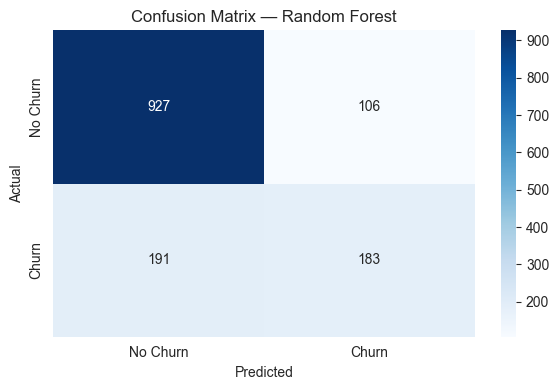

=== Final Model Report ===
              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.86      1033
       Churn       0.63      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



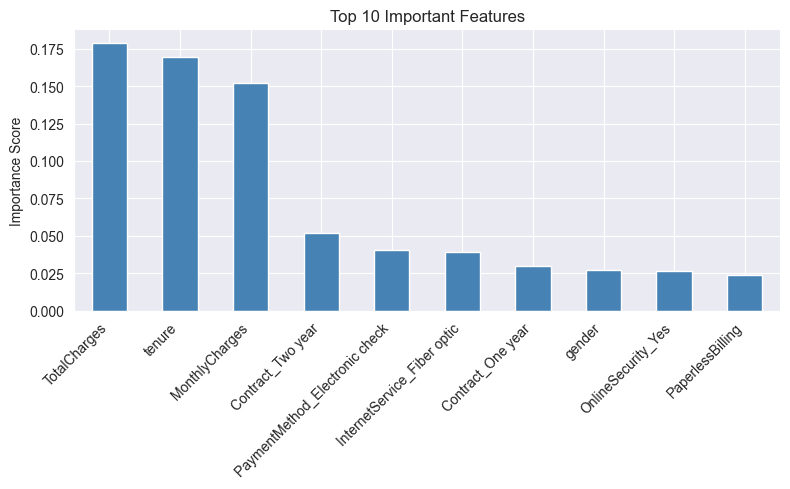


Top 10 Features:
TotalCharges                      0.178893
tenure                            0.169656
MonthlyCharges                    0.152241
Contract_Two year                 0.051952
PaymentMethod_Electronic check    0.040303
InternetService_Fiber optic       0.039097
Contract_One year                 0.029686
gender                            0.027180
OnlineSecurity_Yes                0.026506
PaperlessBilling                  0.024056
dtype: float64


In [9]:
# Confusion Matrix
cm = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix — Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Detailed metrics
print("=== Final Model Report ===")
print(classification_report(y_test, rf_pred,
      target_names=['No Churn', 'Churn']))

# Feature Importance — Top 10
feat_imp = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
feat_imp.head(10).plot(kind='bar', color='steelblue')
plt.title('Top 10 Important Features')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nTop 10 Features:")
print(feat_imp.head(10))